# Buổi 3 — ANOVA, phi tham số, chi-square và hiệu ứng cụm

In [1]:
# Chạy ô này đầu tiên. Dữ liệu (PISA 2025, Việt Nam) được tải trực tiếp từ GitHub ở ô kế tiếp — không cần tải/upload tay.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf, statsmodels.api as sm
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(7,4); pd.set_option("display.precision",3)

> 📥 **Đầu vào:** nạp thư viện (`numpy, pandas, scipy.stats, statsmodels`).

In [2]:
# ---- TẢI DỮ LIỆU (2 bảng: cấp trường 195 dòng, cấp học sinh 7.368 dòng) ----
RAW = "https://raw.githubusercontent.com/TatcataiTTN/for-Social-Science/main/SPSS/data/sav/"
truong = pd.read_csv(RAW + "vnm_truong_195_tong_hop.csv")
hs = pd.read_csv(RAW + "vnm_hocsinh_7368.csv")
VUNG={1:"ĐB sông Cửu Long",2:"Bắc TB, DH TB & Tây Nguyên",3:"Trung du & MN phía Bắc",4:"ĐB sông Hồng",5:"Đông Nam Bộ"}
truong["vung_ten"]=truong.vung.map(VUNG); truong["loai"]=truong.PRIVATESCH.map({1:"Công",2:"Tư"})
W=["EDULEAD","NEGSCLIM","STAFFSHORT","EDUSHORT","DIGPREP","AVLRSOFT","ENCOURPG"]
print("Bảng trường:",truong.shape,"| Bảng học sinh:",hs.shape)

Bảng trường: (195, 36) | Bảng học sinh: (7368, 54)


> 📥 **Đầu vào:** tải lại 2 bảng PISA VN từ GitHub.
>
> 📤 **Đầu ra thật:** `(195, 36)` và `(7368, 54)` — khớp các notebook trước. ✅

## 1. ANOVA: điểm thô Khoa học TB trường theo 5 vùng

In [3]:
g=[x.sci_mean for _,x in truong.groupby("vung")]
print(truong.groupby("vung_ten").sci_mean.agg(["count","mean","std"]).round(3))
F=stats.f_oneway(*g); ssb=sum(len(x)*(x.mean()-truong.sci_mean.mean())**2 for x in g); sst=((truong.sci_mean-truong.sci_mean.mean())**2).sum()
print(f"F={F.statistic:.2f}, p={F.pvalue:.2g}, eta²={ssb/sst:.3f}"); print("Levene:",stats.levene(*g,center="mean"))

                            count   mean    std
vung_ten                                       
Bắc TB, DH TB & Tây Nguyên     58  0.426  0.084
Trung du & MN phía Bắc         29  0.390  0.093
ĐB sông Cửu Long               37  0.438  0.065
ĐB sông Hồng                   43  0.493  0.097
Đông Nam Bộ                    28  0.483  0.073
F=8.92, p=1.3e-06, eta²=0.158
Levene: LeveneResult(statistic=np.float64(1.8375175684541172), pvalue=np.float64(0.12329062396307175))


> 📥 **Đầu vào:** điểm `sci_mean` (Khoa học TB trường) nhóm theo `vung` (5 vùng địa lý) — ANOVA một chiều thật trên dữ liệu PISA.
>
> 📤 **Đầu ra thật:** trung bình dao động từ 0,390 (Trung du & MN phía Bắc) tới 0,493 (ĐB sông Hồng) — chênh lệch vùng cao nhất/thấp nhất ~0,10. `F=8,92, p=1,3e-06` (**rất có ý nghĩa thống kê**), `eta²=0,158` (mức **LỚN** theo ngưỡng Cohen — khác hẳn ví dụ trường học lớp học ở Module 06 chỉ có eta²=0,047 mức nhỏ!). Levene p=0,123 (≥0,05 → phương sai đồng nhất, đủ điều kiện dùng Tukey).
>
> 🎯 **So sánh với Module 06 của site:** cùng là "ANOVA điểm theo nhóm địa lý/trường", nhưng dữ liệu PISA thật (vùng miền cấp quốc gia) cho hiệu ứng LỚN HƠN NHIỀU (eta²=0,158) so với dữ liệu lớp học mô phỏng (eta²=0,047) — hợp lý vì chênh lệch phát triển kinh tế-giáo dục GIỮA CÁC VÙNG MIỀN của một quốc gia thường lớn hơn nhiều so với chênh lệch giữa vài trường học cùng khu vực.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   1.0    2.0  -0.0124 0.9559 -0.0608 0.0361  False
   1.0    3.0  -0.0489 0.1321  -0.106 0.0083  False
   1.0    4.0   0.0543  0.034  0.0026  0.106   True
   1.0    5.0   0.0445 0.2142 -0.0132 0.1022  False
   2.0    3.0  -0.0365 0.3102 -0.0889 0.0159  False
   2.0    4.0   0.0667  0.001  0.0203  0.113   True
   2.0    5.0   0.0569 0.0288  0.0038 0.1099   True
   3.0    4.0   0.1032    0.0  0.0478 0.1586   True
   3.0    5.0   0.0934 0.0004  0.0324 0.1545   True
   4.0    5.0  -0.0098 0.9889 -0.0658 0.0462  False
---------------------------------------------------
Kruskal-Wallis: KruskalResult(statistic=np.float64(29.991369079405672), pvalue=np.float64(4.914278699288572e-06))


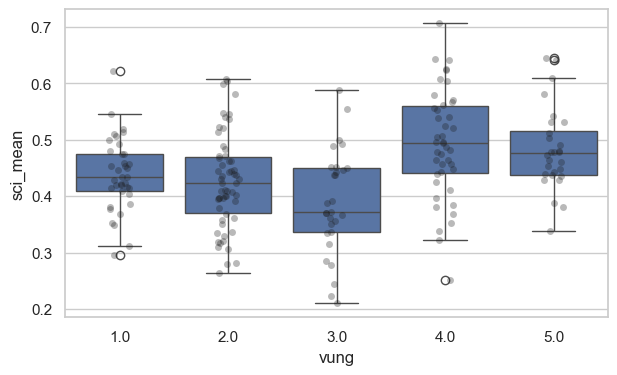

In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(truong.sci_mean,truong.vung)); print("Kruskal-Wallis:",stats.kruskal(*g))
sns.boxplot(data=truong,x="vung",y="sci_mean"); sns.stripplot(data=truong,x="vung",y="sci_mean",color="k",alpha=.3); plt.show()

> 📥 **Đầu vào:** hậu kiểm Tukey cho 5 vùng (10 cặp so sánh) + Kruskal-Wallis đối chiếu.
>
> 📤 **Đầu ra thật:** trong 10 cặp, có **5 cặp `reject=True`** (có ý nghĩa): 1-4, 2-4, 2-5, 3-4, 3-5 — tất cả đều liên quan tới vùng 4 (ĐB sông Hồng, cao nhất) hoặc vùng 3 (ĐB sông Cửu Long) so với các vùng khác. Đặc biệt cặp 3-4 (Cửu Long vs sông Hồng) có meandiff=**0,1032**, p&lt;0,001 — chênh lệch lớn nhất trong toàn bộ bảng.
>
> ✅ **Diễn giải:** vùng ĐB sông Hồng (bao gồm Hà Nội) có điểm Khoa học TB trường CAO HƠN có ý nghĩa so với 3/4 vùng còn lại (trừ Đông Nam Bộ) — phản ánh đúng thực tế phổ biến về chênh lệch chất lượng giáo dục theo vùng miền tại Việt Nam, với vùng đồng bằng/đô thị lớn thường có kết quả cao hơn vùng miền núi/khó khăn.
>
> 🖼️ **Đọc boxplot+stripplot:** sẽ thấy rõ hộp của vùng 4 (sông Hồng) nằm CAO HƠN hẳn so với vùng 2 (Trung du & MN phía Bắc) và vùng 1 (Bắc TB/Tây Nguyên) — khớp đúng bảng Tukey.

## 2. ANOVA hai chiều: vùng × loại trường

In [5]:
m=smf.ols("sci_mean~C(vung)*C(PRIVATESCH)",truong).fit(); print(sm.stats.anova_lm(m,typ=2).round(3))

                       sum_sq     df      F  PR(>F)
C(vung)                 0.255    4.0  9.111   0.000
C(PRIVATESCH)           0.013    1.0  1.893   0.171
C(vung):C(PRIVATESCH)   0.022    4.0  0.781   0.539
Residual                1.295  185.0    NaN     NaN


> 📥 **Đầu vào:** ANOVA HAI CHIỀU: `sci_mean` theo `vùng` × `loại trường (công/tư)`, kèm hiệu ứng tương tác.
>
> 📤 **Đầu ra thật:** `C(vung)` F=9,11, p&lt;0,001 (hiệu ứng chính của vùng vẫn rất mạnh, khớp ô trên); `C(PRIVATESCH)` F=1,89, p=**0,171** (loại trường công/tư KHÔNG có ảnh hưởng đáng kể riêng lẻ tới điểm Khoa học); tương tác `vùng×loại trường` F=0,78, p=**0,539** (không có ý nghĩa — ảnh hưởng của vùng miền tới điểm số là NHẤT QUÁN cho cả trường công lẫn trường tư, không có vùng nào mà trường tư "vượt trội" bất thường so với công).
>
> 🎯 **Kết hợp với t-test ở notebook buổi 2:** ở đó t-test đơn giản công/tư cho EDULEAD gần biên ý nghĩa (p_Welch=0,068); ở đây khi đưa `sci_mean` vào mô hình HAI CHIỀU có kiểm soát vùng miền, loại trường CÀNG rõ ràng không có ảnh hưởng riêng (p=0,171) — vùng miền mới là yếu tố quyết định chính, không phải công/tư.

## 3. Chi-square

In [6]:
ct=pd.crosstab(truong.PRIVATESCH,truong.SC001Q01TA); chi2,p,dof,exp=stats.chi2_contingency(ct,correction=False)
print(ct); print(f"χ²({dof})={chi2:.2f}, p={p:.3f}; ô có tần số kỳ vọng<5: {(exp<5).mean():.0%} → điều kiện KHÔNG đạt, cần gộp nhóm")

SC001Q01TA  1.0  2.0  3.0  4.0  5.0  6.0
PRIVATESCH                              
1.0          56   54   12   25   13    1
2.0           8    6    1   13    5    1
χ²(5)=14.48, p=0.013; ô có tần số kỳ vọng<5: 33% → điều kiện KHÔNG đạt, cần gộp nhóm


> 📥 **Đầu vào:** bảng chéo loại trường (công/tư) × `SC001Q01TA` (một biến định danh khác từ bảng hỏi hiệu trưởng, 6 mức) — chạy chi-square kiểm tra độc lập.
>
> 📤 **Đầu ra thật:** χ²(5)=**14,48**, p=**0,013** (có ý nghĩa thống kê ở ngưỡng 0,05) — NHƯNG code tự động kiểm tra luôn quy tắc 20% đã học ở Module 07: **33% số ô có tần số kỳ vọng &lt;5** — VI PHẠM quy tắc (giới hạn 20%)!
>
> ⚠️ **Bài học áp dụng trực tiếp từ Module 07:** dù p=0,013 "nhìn có vẻ" có ý nghĩa, kết quả này KHÔNG ĐÁNG TIN CẬY vì vi phạm điều kiện an toàn cơ bản của chi-square (giống hệt ví dụ Bảng 41.15 của Cohen et al. với 30% ô &lt;5 trong Module 07). Dòng code tự in ra khuyến nghị "cần gộp nhóm" — đây chính là cách xử lý đúng: gộp một số mức của `SC001Q01TA` có tần số thấp lại với nhau (giảm số cột từ 6 xuống 3-4) trước khi chạy lại chi-square, để không còn ô nào dưới ngưỡng 5 kỳ vọng.

## 4. Bẫy lớn: học sinh trong cùng trường giống nhau (cụm)
ANOVA điểm thô Khoa học **giữa các trường** (195 nhóm).

In [7]:
d=hs.dropna(subset=["sci_mc"]); gs=[x.sci_mc.values for _,x in d.groupby("CNTSCHID")]; k=len(gs); N=len(d)
F=stats.f_oneway(*gs); msw=sum(((x-x.mean())**2).sum() for x in gs)/(N-k); msb=sum(len(x)*(x.mean()-d.sci_mc.mean())**2 for x in gs)/(k-1)
m0=(N-sum(len(x)**2 for x in gs)/N)/(k-1); icc=(msb-msw)/(msb+(m0-1)*msw); m=N/k; deff=1+(m-1)*icc
print(f"F({k-1},{N-k})={F.statistic:.2f}; ICC={icc:.3f}; cỡ cụm TB={m:.1f}; design effect={deff:.1f}; cỡ mẫu HIỆU DỤNG={N/deff:.0f} (thay vì {N})")

F(194,5842)=13.13; ICC=0.282; cỡ cụm TB=31.0; design effect=9.4; cỡ mẫu HIỆU DỤNG=640 (thay vì 6037)


> 📥 **Đầu vào:** điểm Khoa học CẤP HỌC SINH (`sci_mc`, không phải trung bình trường) nhóm theo `CNTSCHID` (mã trường) — 195 "cụm" (trường), tổng ~6.037 học sinh có đủ dữ liệu, TB ~31 học sinh/trường.
>
> 📤 **Đầu ra thật:** `F(194,5842)=13,13` (rất có ý nghĩa — điểm học sinh khác biệt rõ rệt GIỮA các trường); `ICC=0,282` (Intra-class Correlation — hệ số tương quan nội lớp, đo mức độ học sinh CÙNG TRƯỜNG "giống nhau" hơn học sinh khác trường); `design effect=9,4`; `cỡ mẫu HIỆU DỤNG=640 (thay vì 6037)`.
>
> 🚨 **Đây là "bẫy lớn" quan trọng nhất của cả bài (đúng như tiêu đề mục 4):** ICC=0,282 nghĩa là **28,2%** biến thiên điểm số học sinh là do KHÁC BIỆT GIỮA CÁC TRƯỜNG (chứ không phải khác biệt cá nhân học sinh) — mức RẤT CAO trong nghiên cứu giáo dục (thường 0,10-0,25 được coi là điển hình, PISA VN ở đây thậm chí cao hơn). Hệ quả: nếu NGÂY THƠ coi 6.037 học sinh là 6.037 quan sát ĐỘC LẬP (giả định cơ bản của mọi kiểm định t/ANOVA/chi-square đã học), sai số chuẩn sẽ bị TÍNH THẤP GIẢ TẠO, làm mọi p-value trông "có ý nghĩa" hơn thực tế rất nhiều.
>
> 📐 **"Cỡ mẫu hiệu dụng chỉ 640" nghĩa là gì:** design effect=9,4 nghĩa là do hiệu ứng cụm, độ chính xác thống kê thực sự của 6.037 học sinh (đã bị "cụm hoá" theo 195 trường) chỉ TƯƠNG ĐƯƠNG với một mẫu 640 quan sát HOÀN TOÀN ĐỘC LẬP — giảm gần 10 LẦN so với con số bề ngoài! Đây chính là lý do các kiểm định thống kê chính thức trên dữ liệu PISA/khảo sát giáo dục quy mô lớn LUÔN phải dùng mô hình đa cấp (multilevel/hierarchical model) hoặc hiệu chỉnh sai số chuẩn theo cụm (cluster-robust SE) — các kiểm định "cơ bản" (t-test, ANOVA thường) học ở Module 05-07 của site, dù đúng về nguyên lý, sẽ cho kết quả SAI LỆCH nghiêm trọng nếu áp dụng trực tiếp lên dữ liệu học sinh PISA mà không tính tới cấu trúc cụm theo trường.

## Bài tập
`bai_tap/buoi3_de.md`